In [21]:
import getpass
import os


def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")


_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("TAVILY_API_KEY")

In [3]:
!pip install matplotlib langchain-tavily

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.1 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.3 MB 1.8 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.3 MB 2.0 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.3 MB 2.4 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.3 MB 2.6 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 3.2 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.3 MB 3.4 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 8.3/

In [22]:
from typing import Annotated

from langchain_tavily import TavilyResearch
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

tavily_tool=TavilyResearch(max_results=5)
repl = PythonREPL()

@tool
def python_repl_tool(code: Annotated[str, "the python code to execute to generate your chart"]):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result  = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repl(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
         result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )


In [23]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

In [34]:
from typing import Literal

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

llm=ChatOpenAI(model="gpt-4o")

def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto

research_agent = create_react_agent(
    llm,
    tools=[tavily_tool],
    prompt=make_system_prompt("you can only do resesarch. you are working with chart generator collegue"
                             )
)

def research_node(state: MessagesState ):
    result= research_agent.invoke(state)
    goto=get_next_node(result["messages"][-1], "chart_generator")
    result["messages"][-1]=HumanMessage(content=result["messages"][-1].content, name = "researcher")
    return Command(
        update={
            "messages": result["messages"]
        },
        goto=goto
    )


chart_agent = create_react_agent(
    llm,
    [python_repl_tool],
    prompt=make_system_prompt("you can only generate charts, you are working with researcher collegue")
)


def chart_node(state: MessagesState):
    result=chart_agent.invoke(state)
    goto=get_next_node(result["messages"][-1], "researcher")
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="chart_generator"
    )
    return Command(
        update={
            "messages": result["messages"]
        },
        goto=goto
    )
    

C:\Users\Narisetti Chand\AppData\Local\Temp\ipykernel_32392\1927013763.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(
C:\Users\Narisetti Chand\AppData\Local\Temp\ipykernel_32392\1927013763.py:35: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_agent = create_react_agent(


In [35]:
from langgraph.graph import START, StateGraph

workflow=StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_edge(START, "researcher")
graph=workflow.compile()

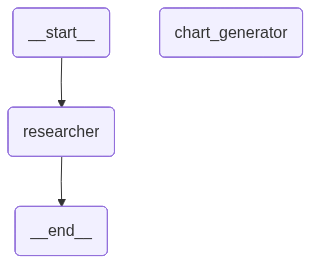

In [36]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [37]:
events = graph.stream(
    {
        "messages": [
            (
                "user",
                "get the gold and silver prices from last two months of 2026 "
                "Once you make the chart, finish.",
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    print(s)
    print("----")

{'researcher': {'messages': [HumanMessage(content='get the gold and silver prices from last two months of 2026 Once you make the chart, finish.', additional_kwargs={}, response_metadata={}, id='941f2bb9-c94d-4170-911b-9f4791eec914'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 642, 'total_tokens': 675, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_92d15debfd', 'id': 'chatcmpl-DNeMUKZW56lJporKVWsh7uCUPj2Ep', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d2a2c-b4ea-7b21-9ceb-9fcda350ac9e-0', tool_calls=[{'name': 'tavily_research', 'args': {'input': 'Gold and Silver prices for the last two months of 2026', 'm